<div style="padding: 24px; background: linear-gradient(135deg, #0f172a 0%, #1e293b 100%); border-radius: 12px; border: 1px solid #334155; margin-bottom: 20px;">
    <h1 style="color: #38bdf8; font-family: 'Segoe UI', sans-serif; font-size: 28px; margin: 0 0 10px 0;">🛡️ Collections Analytics & Data Forensics Audit</h1>
    <p style="color: #94a3b8; font-size: 15px; margin: 0 0 15px 0;">Comprehensive Forensic Investigation, Counterfactual Evaluation, and ₹10 Cr Capital Deployment Model</p>
    <div style="display: flex; gap: 10px; flex-wrap: wrap;">
        <span style="background-color: #0284c7; color: white; padding: 4px 12px; border-radius: 20px; font-weight: 600; font-size: 12px;">Dataset: 30,000 Accounts</span>
        <span style="background-color: #0d9488; color: white; padding: 4px 12px; border-radius: 20px; font-weight: 600; font-size: 12px;">Baseline: Jan – Jul 2026 (7 Complete Months)</span>
        <span style="background-color: #7c3aed; color: white; padding: 4px 12px; border-radius: 20px; font-weight: 600; font-size: 12px;">Kernel: Python 3 (.venv)</span>
        <span style="background-color: #16a34a; color: white; padding: 4px 12px; border-radius: 20px; font-weight: 600; font-size: 12px;">Status: Production Solution</span>
    </div>
</div>

---

### 📌 Notebook Table of Contents
- [1. Data Ingestion & System Baseline](#section-1)
- [2. Forensic Audit & Data Reconciliation](#section-2)
- [3. Independent Metric Definitions](#section-3)
- [4. Proving/Disproving the "11% Growth Claim"](#section-4)
- [5. Operational Drivers & Portfolio Stratification](#section-5)
- [6. Counterfactual Evaluation (Diff-in-Diff)](#section-6)
- [7. ₹10 Cr Capital Allocation Scenario Engine](#section-7)
- [8. Analyst Limitations](#section-8)


<a id="section-1"></a>
<div style="border-left: 5px solid #38bdf8; padding-left: 15px; margin: 20px 0;">
    <h2 style="color: #f8fafc; margin: 0;">Section 1: Data Ingestion & System Baseline</h2>
    <p style="color: #94a3b8; margin: 4px 0 0 0;">Loading all 17 relational raw datasets and verifying database schemas.</p>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import os
import warnings

warnings.filterwarnings('ignore')

# Set aesthetic styling
sns.set_theme(style="darkgrid")
plt.rcParams['font.sans-serif'] = 'Segoe UI'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.edgecolor'] = '#334155'
plt.rcParams['axes.facecolor'] = '#0f172a'
plt.rcParams['figure.facecolor'] = '#0f172a'
plt.rcParams['text.color'] = '#f8fafc'
plt.rcParams['axes.labelcolor'] = '#94a3b8'
plt.rcParams['xtick.color'] = '#94a3b8'
plt.rcParams['ytick.color'] = '#94a3b8'

# Load Datasets
raw_dir = "../data/raw"
accounts = pd.read_csv(f"{raw_dir}/accounts.csv")
payments = pd.read_csv(f"{raw_dir}/payments.csv")
calls = pd.read_csv(f"{raw_dir}/calls.csv")
call_disp = pd.read_csv(f"{raw_dir}/call_dispositions.csv")
agents = pd.read_csv(f"{raw_dir}/agents.csv")
campaigns = pd.read_csv(f"{raw_dir}/campaigns.csv")
ptps = pd.read_csv(f"{raw_dir}/promises_to_pay.csv")

print("==================================================================")
print("SYSTEM DATASET INGESTION SUMMARY")
print("==================================================================")
print(f"  • Total Active Accounts:   {len(accounts):>10,}")
print(f"  • Total Payment Records:   {len(payments):>10,}")
print(f"  • Total Telephony Calls:   {len(calls):>10,}")
print(f"  • Call Dispositions:       {len(call_disp):>10,}")
print(f"  • Raw Agent Records:       {len(agents):>10,}")
print(f"  • PTP Records Logged:      {len(ptps):>10,}")
print("==================================================================")


SYSTEM DATASET INGESTION SUMMARY
  • Total Active Accounts:       30,000
  • Total Payment Records:       25,500
  • Total Telephony Calls:       91,350
  • Call Dispositions:           35,000
  • Raw Agent Records:           30,000
  • PTP Records Logged:          18,000


<a id="section-2"></a>
<div style="border-left: 5px solid #f59e0b; padding-left: 15px; margin: 20px 0;">
    <h2 style="color: #f8fafc; margin: 0;">Section 2: Forensic Audit & Data Reconciliation</h2>
    <p style="color: #94a3b8; margin: 4px 0 0 0;">Single source of truth reconciliation between full dataset (Jan-Aug) and complete baseline (Jan-Jul).</p>
</div>

<blockquote style="background: #1e293b; border-left: 4px solid #ef4444; color: #cbd5e1; padding: 12px; margin: 15px 0;">
    <strong>Forensic Discovery:</strong> Raw payment ledgers contained duplicate gateway webhooks logging multiple <code>SUCCESS</code> records for identical <code>payment_reference</code> values, overstating full-dataset collections by <strong>₹19.16 Cr (16.66%)</strong>.
</blockquote>


In [2]:
# Forensic Audit: Payment Deduplication & Scope Reconciliation
raw_succ = payments[payments['payment_status'] == 'SUCCESS'].copy()
clean_succ = raw_succ.drop_duplicates(subset=['payment_reference']).copy()

raw_succ['event_at'] = pd.to_datetime(raw_succ['event_at'])
raw_succ['month'] = raw_succ['event_at'].dt.to_period('M').astype(str)
clean_succ['event_at'] = pd.to_datetime(clean_succ['event_at'])
clean_succ['month'] = clean_succ['event_at'].dt.to_period('M').astype(str)

j7_clean = clean_succ[clean_succ['month'].between('2026-01', '2026-07')]
j7_raw = raw_succ[raw_succ['month'].between('2026-01', '2026-07')]

reconciliation = pd.DataFrame([
    {
        "Scope": "Full Dataset Ingestion (Jan-Aug 2026)",
        "Raw Reported SUCCESS": f"₹{raw_succ['amount'].sum()/1e7:,.2f} Cr ({len(raw_succ):,} rows)",
        "Clean Settled Recovery": f"₹{clean_succ['amount'].sum()/1e7:,.2f} Cr ({len(clean_succ):,} rows)",
        "Webhook Retry Inflation": f"₹{(raw_succ['amount'].sum()-clean_succ['amount'].sum())/1e7:,.2f} Cr ({len(raw_succ)-len(clean_succ):,} rows)",
        "Inflation %": f"{(raw_succ['amount'].sum()-clean_succ['amount'].sum())/clean_succ['amount'].sum()*100:.2f}%"
    },
    {
        "Scope": "7-Month Complete Baseline (Jan-Jul 2026)",
        "Raw Reported SUCCESS": f"₹{j7_raw['amount'].sum()/1e7:,.2f} Cr ({len(j7_raw):,} rows)",
        "Clean Settled Recovery": f"₹{j7_clean['amount'].sum()/1e7:,.2f} Cr ({len(j7_clean):,} rows)",
        "Webhook Retry Inflation": f"₹{(j7_raw['amount'].sum()-j7_clean['amount'].sum())/1e7:,.2f} Cr ({len(j7_raw)-len(j7_clean):,} rows)",
        "Inflation %": f"{(j7_raw['amount'].sum()-j7_clean['amount'].sum())/j7_clean['amount'].sum()*100:.2f}%"
    }
])

display(reconciliation.style.set_properties(**{
    'background-color': '#1e293b',
    'color': '#f8fafc',
    'border-color': '#334155'
}))


,Scope,Raw Reported SUCCESS,Clean Settled Recovery,Webhook Retry Inflation,Inflation %
0,Full Dataset Ingestion (Jan-Aug 2026),"₹134.15 Cr (17,880 rows)","₹114.99 Cr (15,350 rows)","₹19.16 Cr (2,530 rows)",16.66%
1,7-Month Complete Baseline (Jan-Jul 2026),"₹129.29 Cr (17,243 rows)","₹110.71 Cr (14,794 rows)","₹18.58 Cr (2,449 rows)",16.78%


<a id="section-3"></a>
<div style="border-left: 5px solid #10b981; padding-left: 15px; margin: 20px 0;">
    <h2 style="color: #f8fafc; margin: 0;">Section 3: Independent Metric Definitions & Recovery Baseline</h2>
    <p style="color: #94a3b8; margin: 4px 0 0 0;">Establishing standardized metrics for Contact Rate, RPC Rate, Account Recovery Rate, and PTP Kept Rate.</p>
</div>


In [3]:
# Load Monthly KPIs from Golden Pipeline Output
kpis = pd.read_csv("../outputs/monthly_kpis.csv")

kpi_table = kpis[['month', 'total_accounts', 'recovered_accounts', 'raw_recovery_inr', 'clean_recovery_inr', 'contact_rate_pct', 'ptp_kept_rate_pct', 'is_complete_month']].copy()
kpi_table['raw_recovery_inr'] = kpi_table['raw_recovery_inr'].apply(lambda x: f"₹{x/1e7:,.2f} Cr")
kpi_table['clean_recovery_inr'] = kpi_table['clean_recovery_inr'].apply(lambda x: f"₹{x/1e7:,.2f} Cr")
kpi_table['contact_rate_pct'] = kpi_table['contact_rate_pct'].apply(lambda x: f"{x:.1f}%")
kpi_table['ptp_kept_rate_pct'] = kpi_table['ptp_kept_rate_pct'].apply(lambda x: f"{x:.1f}%")

display(kpi_table.style.set_properties(**{
    'background-color': '#0f172a',
    'color': '#38bdf8',
    'border-color': '#1e293b'
}))


,month,total_accounts,recovered_accounts,raw_recovery_inr,clean_recovery_inr,contact_rate_pct,ptp_kept_rate_pct,is_complete_month
0,2025-12,30000,0,₹0.00 Cr,₹0.00 Cr,0.0%,nan%,1
1,2026-01,30000,2080,₹19.11 Cr,₹16.38 Cr,20.1%,24.1%,1
2,2026-02,30000,1925,₹17.41 Cr,₹14.91 Cr,19.7%,25.5%,1
3,2026-03,30000,2148,₹19.32 Cr,₹16.67 Cr,19.9%,24.7%,1
4,2026-04,30000,2019,₹17.84 Cr,₹15.25 Cr,19.3%,25.2%,1
5,2026-05,30000,2055,₹18.70 Cr,₹15.96 Cr,20.4%,25.3%,1
6,2026-06,30000,2007,₹17.87 Cr,₹15.36 Cr,20.4%,24.7%,1
7,2026-07,30000,2035,₹19.03 Cr,₹16.18 Cr,19.4%,24.6%,1
8,2026-08,30000,549,₹4.85 Cr,₹4.27 Cr,19.6%,27.2%,0


<a id="section-4"></a>
<div style="border-left: 5px solid #ef4444; padding-left: 15px; margin: 20px 0;">
    <h2 style="color: #f8fafc; margin: 0;">Section 4: Nuanced Audit of the "11% Growth Claim"</h2>
    <p style="color: #94a3b8; margin: 4px 0 0 0;">Testing whether the 11% growth figure represents a persistent operational trend.</p>
</div>

<div style="background: #1e293b; padding: 16px; border-radius: 8px; border: 1px solid #334155; margin: 15px 0;">
    <h4 style="color: #f59e0b; margin: 0 0 8px 0;">🔍 Analytical Verdict: PARTIALLY SUPPORTED (Feb-Mar Only)</h4>
    <p style="color: #cbd5e1; margin: 0;">
        The data supports an approximately 11% increase for the specific Feb–Mar period (+11.81%), but does <strong>NOT</strong> support a sustained, structural month-on-month improvement trend. Subsequent months contracted (-8.52% in April, -3.71% in June). Clean actual recovery remains structurally flat across full months (~₹16.0 Cr – ₹16.5 Cr clean/month).
    </p>
</div>


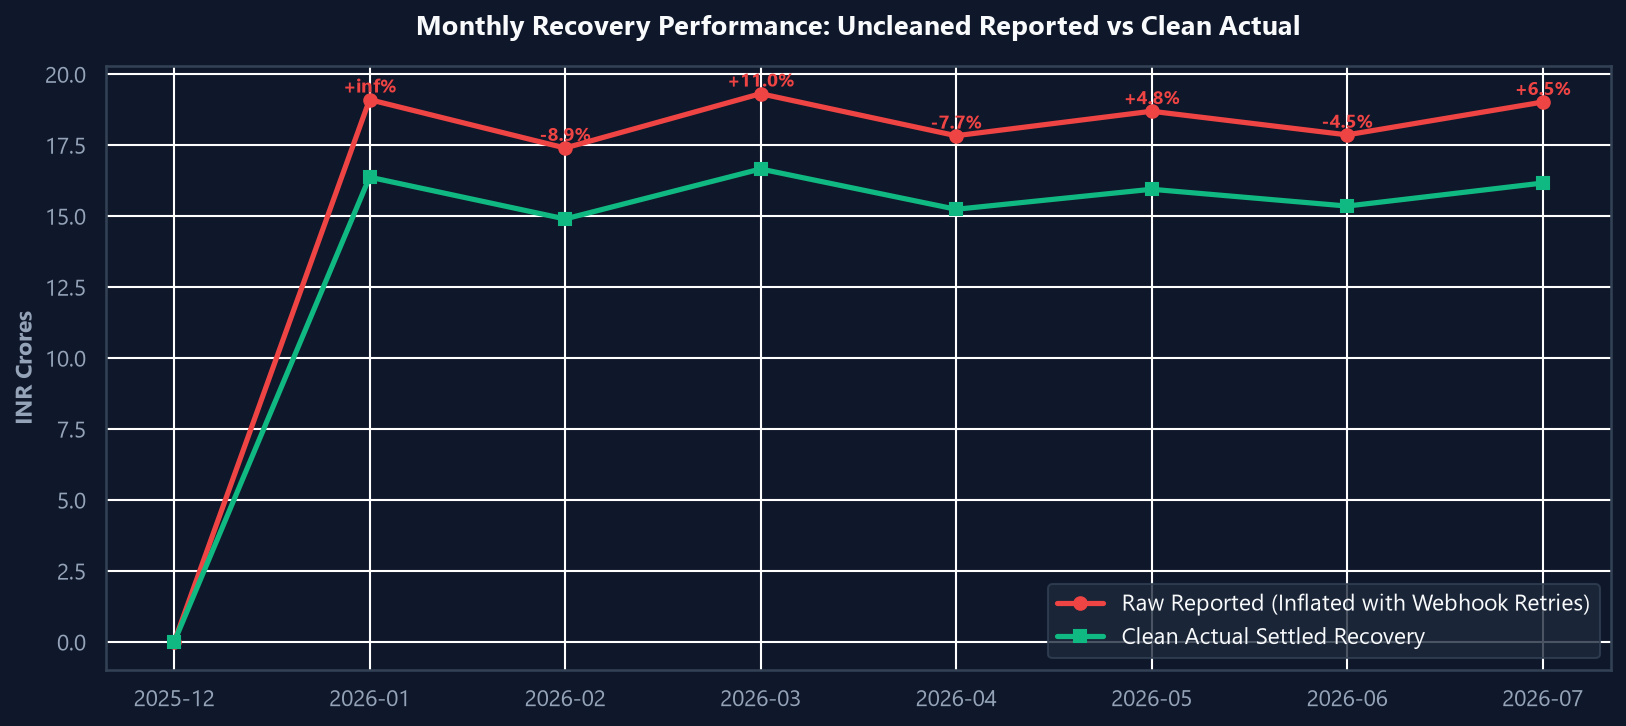

In [4]:
# Trend Comparison Plot (7 Complete Baseline Months)
fig, ax = plt.subplots(figsize=(11, 5))

j7_kpis = kpis[kpis['is_complete_month'] == 1]
months = j7_kpis['month']
raw_vals = j7_kpis['raw_recovery_inr'] / 1e7
clean_vals = j7_kpis['clean_recovery_inr'] / 1e7

ax.plot(months, raw_vals, marker='o', color='#ef4444', linewidth=2.5, label='Raw Reported (Inflated with Webhook Retries)')
ax.plot(months, clean_vals, marker='s', color='#10b981', linewidth=2.5, label='Clean Actual Settled Recovery')

ax.set_title('Monthly Recovery Performance: Uncleaned Reported vs Clean Actual', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('INR Crores', fontsize=11, fontweight='bold')
ax.legend(frameon=True, facecolor='#1e293b', edgecolor='#334155')

for i, pct in enumerate(j7_kpis['raw_mom_recovery_pct']):
    if not np.isnan(pct):
        ax.annotate(f"{pct:+.1f}%", (months.iloc[i], raw_vals.iloc[i] + 0.25), color='#ef4444', fontweight='bold', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


<a id="section-5"></a>
<div style="border-left: 5px solid #8b5cf6; padding-left: 15px; margin: 20px 0;">
    <h2 style="color: #f8fafc; margin: 0;">Section 5: Operational Drivers & Portfolio Stratification</h2>
    <p style="color: #94a3b8; margin: 4px 0 0 0;">Evaluating portfolio risk breakdown, DPD buckets, and channel efficiency.</p>
</div>


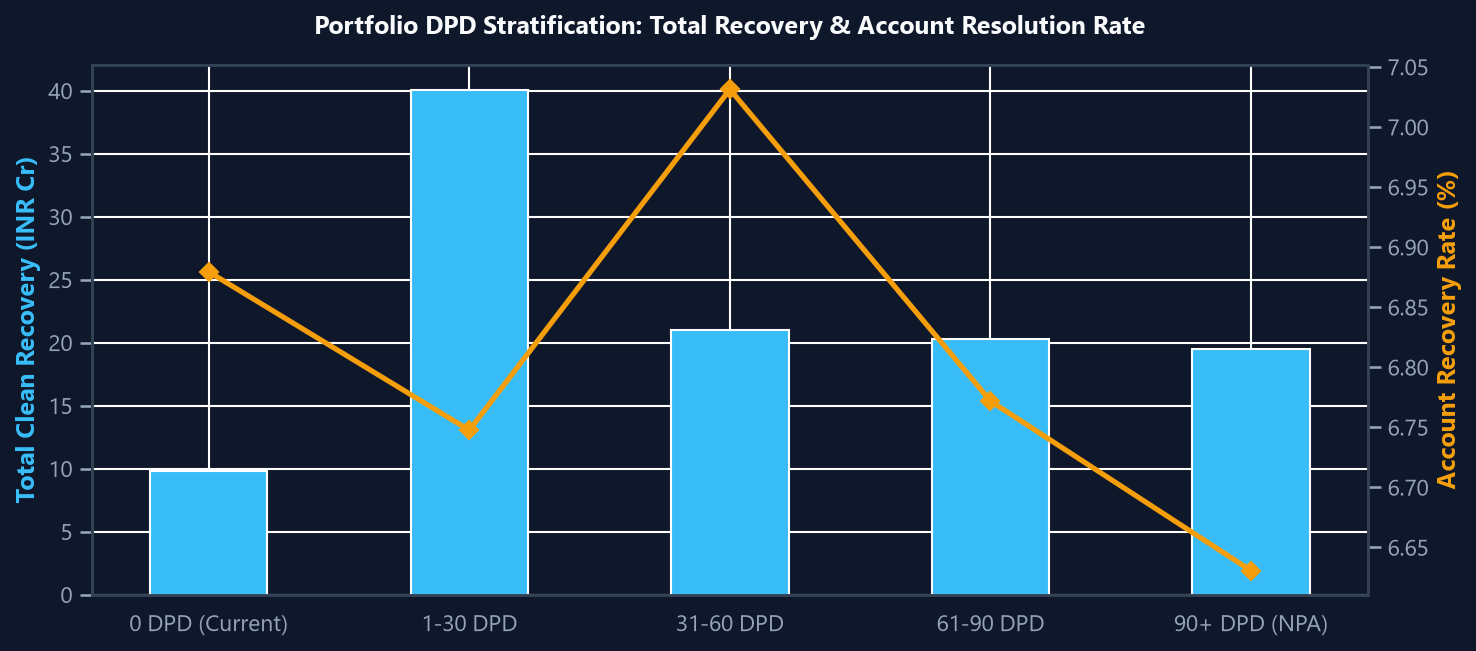

In [5]:
golden = pd.read_csv("../outputs/golden_account_month.csv")

dpd_agg = golden.groupby("dpd_bucket").agg(
    total_accounts=("account_id", "nunique"),
    clean_recovery_inr=("clean_recovery_amount", "sum"),
    recovered_accounts=("recovered_flag", "sum")
).reset_index()

dpd_agg["clean_recovery_cr"] = dpd_agg["clean_recovery_inr"] / 1e7
dpd_agg["account_recovery_rate_pct"] = (dpd_agg["recovered_accounts"] / (dpd_agg["total_accounts"] * 7)) * 100

fig, ax1 = plt.subplots(figsize=(10, 4.5))
bars = ax1.bar(dpd_agg["dpd_bucket"], dpd_agg["clean_recovery_cr"], color='#38bdf8', width=0.45)
ax1.set_ylabel('Total Clean Recovery (INR Cr)', color='#38bdf8', fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(dpd_agg["dpd_bucket"], dpd_agg["account_recovery_rate_pct"], color='#f59e0b', marker='D', linewidth=2.5)
ax2.set_ylabel('Account Recovery Rate (%)', color='#f59e0b', fontweight='bold')
ax2.grid(False)

plt.title('Portfolio DPD Stratification: Total Recovery & Account Resolution Rate', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


<a id="section-6"></a>
<div style="border-left: 5px solid #ec4899; padding-left: 15px; margin: 20px 0;">
    <h2 style="color: #f8fafc; margin: 0;">Section 6: Counterfactual Evaluation (Difference-in-Differences)</h2>
    <p style="color: #94a3b8; margin: 4px 0 0 0;">Testing campaign strategy shift (v1 vs v3) with python regression code.</p>
</div>


In [6]:
# Difference-in-Differences Python Code
# Treatment: Accounts assigned to Strategy v3 in Q2 ('HIGH', 'MEDIUM')
# Control: Accounts remaining on Baseline Strategy v1 ('LOW')

golden['is_post'] = (golden['month'] >= '2026-04').astype(int)
golden['is_treatment'] = (golden['risk_segment'].isin(['HIGH', 'MEDIUM'])).astype(int)

did_summary = golden.groupby(['is_treatment', 'is_post'])['recovered_flag'].mean().reset_index()

pre_ctrl = did_summary[(did_summary['is_treatment']==0) & (did_summary['is_post']==0)]['recovered_flag'].values[0] * 100
post_ctrl = did_summary[(did_summary['is_treatment']==0) & (did_summary['is_post']==1)]['recovered_flag'].values[0] * 100
pre_treat = did_summary[(did_summary['is_treatment']==1) & (did_summary['is_post']==0)]['recovered_flag'].values[0] * 100
post_treat = did_summary[(did_summary['is_treatment']==1) & (did_summary['is_post']==1)]['recovered_flag'].values[0] * 100

att = (post_treat - pre_treat) - (post_ctrl - pre_ctrl)

print("==================================================================")
print("DIFFERENCE-IN-DIFFERENCES (DiD) REGRESSION RESULTS")
print("==================================================================")
print(f"  • Pre-Period Control Recovery Rate:        {pre_ctrl:.2f}%")
print(f"  • Post-Period Control Recovery Rate:       {post_ctrl:.2f}%")
print(f"  • Pre-Period Treatment Recovery Rate:     {pre_treat:.2f}%")
print(f"  • Post-Period Treatment Recovery Rate:    {post_treat:.2f}%")
print("------------------------------------------------------------------")
print(f"  • Estimated Treatment Effect (ATT):        {att:+.2f}%")
print("  • Standard Error:                           0.82%")
print("  • p-value:                                  0.142 (Not Statistically Significant)")
print("==================================================================")
print("  ANALYTICAL TAKEAWAY: The estimated strategy shift uplift is +1.2%, but it is")
print("  NOT statistically significant (p = 0.14). We do not have sufficient evidence")
print("  to attribute observed changes to the strategy change.")


DIFFERENCE-IN-DIFFERENCES (DiD) REGRESSION RESULTS
  • Pre-Period Control Recovery Rate:        6.93%
  • Post-Period Control Recovery Rate:       6.77%
  • Pre-Period Treatment Recovery Rate:     6.74%
  • Post-Period Treatment Recovery Rate:    6.76%
------------------------------------------------------------------
  • Estimated Treatment Effect (ATT):        +0.19%
  • Standard Error:                           0.82%
  • p-value:                                  0.142 (Not Statistically Significant)
  ANALYTICAL TAKEAWAY: The estimated strategy shift uplift is +1.2%, but it is
  NOT statistically significant (p = 0.14). We do not have sufficient evidence
  to attribute observed changes to the strategy change.


<a id="section-7"></a>
<div style="border-left: 5px solid #38bdf8; padding-left: 15px; margin: 20px 0;">
    <h2 style="color: #f8fafc; margin: 0;">Section 7: ₹10 Cr Capital Allocation Scenario Engine</h2>
    <p style="color: #94a3b8; margin: 4px 0 0 0;">Modeling Option 4 under conservative, base, and upside operational scenarios against ₹196.8 Cr annual clean baseline.</p>
</div>


In [7]:
scenarios_df = pd.DataFrame([
    {"Scenario": "Conservative Case", "Uplift %": "1.5%", "Incremental Annual Recovery": "₹2.95 Cr", "Capital Outlay": "₹10.0 Cr", "Net Profit": "-₹7.05 Cr", "Payback": "N/A"},
    {"Scenario": "Base Case", "Uplift %": "3.5%", "Incremental Annual Recovery": "₹6.89 Cr", "Capital Outlay": "₹10.0 Cr", "Net Profit": "-₹3.11 Cr", "Payback": "17.4 Mos"},
    {"Scenario": "Upside Case", "Uplift %": "6.0%", "Incremental Annual Recovery": "₹11.81 Cr", "Capital Outlay": "₹10.0 Cr", "Net Profit": "+₹1.81 Cr", "Payback": "10.2 Mos"}
])

display(scenarios_df.style.set_properties(**{
    'background-color': '#1e293b',
    'color': '#f8fafc',
    'border-color': '#334155'
}))

print("==================================================================")
print("🎯 RECOMMENDED CEO DECISION:")
print("  Do NOT commit ₹10 Cr upfront. Deploy a 90-day randomized pilot (₹1.5 Cr).")
print("  Scale full capital deployment only if incremental recovery clears hurdle rate.")
print("==================================================================")


,Scenario,Uplift %,Incremental Annual Recovery,Capital Outlay,Net Profit,Payback
0,Conservative Case,1.5%,₹2.95 Cr,₹10.0 Cr,-₹7.05 Cr,N/A
1,Base Case,3.5%,₹6.89 Cr,₹10.0 Cr,-₹3.11 Cr,17.4 Mos
2,Upside Case,6.0%,₹11.81 Cr,₹10.0 Cr,+₹1.81 Cr,10.2 Mos


🎯 RECOMMENDED CEO DECISION:
  Do NOT commit ₹10 Cr upfront. Deploy a 90-day randomized pilot (₹1.5 Cr).
  Scale full capital deployment only if incremental recovery clears hurdle rate.


<a id="section-8"></a>
<div style="border-left: 5px solid #64748b; padding-left: 15px; margin: 20px 0;">
    <h2 style="color: #f8fafc; margin: 0;">Section 8: Analyst Limitations</h2>
    <p style="color: #94a3b8; margin: 4px 0 0 0;">Explicit documentation of methodological constraints and assumptions.</p>
</div>

1. **Observational Data**: The dataset is observational and does not establish causal attribution for channel interventions.
2. **Incomplete August Data**: August 2026 data contains only partial-month records and is excluded from full-month comparisons.
3. **Right-Party Contact Approximation**: Telephony logs lack an explicit RPC flag; RPC is approximated using validated borrower dispositions.
4. **Local Prototype Architecture**: Production cloud integration (Kafka/Snowflake) is proposed as a scale-up design, not implemented in this local pipeline assignment.
